# Compressed Sensing MRI 

Python Starter Code for Prof. Miki Lustig's Compressive Sensing MRI assignment. https://people.eecs.berkeley.edu/~mlustig/CS.html 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import pywt
from scipy.fft import fft, ifft, fft2, ifft2, fftshift, ifftshift
from IPython.display import clear_output

## Helper Functions

These functions are provided for you. Run this cell before proceeding.

In [3]:
def fftc(x, axis=-1):
    """Centered 1D FFT with orthonormal scaling."""
    N = x.shape[axis]
    return fftshift(fft(ifftshift(x, axes=axis), axis=axis), axes=axis) / np.sqrt(N)


def ifftc(x, axis=-1):
    """Centered 1D inverse FFT with orthonormal scaling."""
    N = x.shape[axis]
    return fftshift(ifft(ifftshift(x, axes=axis), axis=axis), axes=axis) * np.sqrt(N)


def fft2c(x):
    """Centered 2D FFT with orthonormal scaling."""
    return fftshift(fft2(ifftshift(x))) / np.sqrt(x.size)


def ifft2c(x):
    """Centered 2D inverse FFT with orthonormal scaling."""
    return fftshift(ifft2(ifftshift(x))) * np.sqrt(x.size)


print("✓ Helper functions loaded!")

✓ Helper functions loaded!


---
# Part 1: Sparse Signals and Denoising

To get an intuition, let's first explore the world of sparse 1D signals.

## 1a) Sparse Signals - Tikhonov Regularization

Before we start with compressed sensing, we'll look at sparse signal denoising. There's a strong connection between CS and denoising.

### Task 1.1: Generate and visualize a sparse signal

Generate a 1×128 vector `x` with 5 non-zero coefficients `[1:5]/5` and permute them randomly

Add random Gaussian noise with standard deviation σ = 0.05 to the signal: `y = x + n`

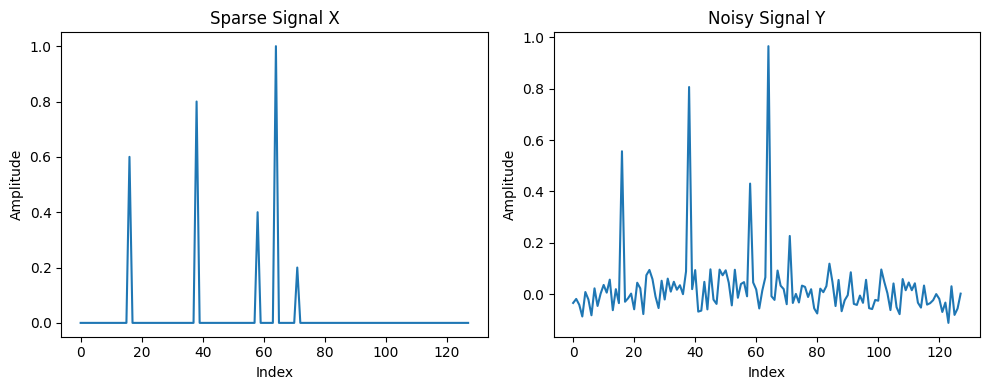

In [4]:
# Set random seed for reproducibility
np.random.seed(0)
N = 128

# TODO: Generate sparse signal x with 5 non-zero coefficients
# Hint: Create array [0.2, 0.4, 0.6, 0.8, 1.0] followed by zeros, then permute
dense = np.array([0.2, 0.4, 0.6, 0.8, 1.0])
zeros = np.zeros(N - len(dense))
x = np.concatenate([dense, zeros])
np.random.shuffle(x)

# TODO: Add Gaussian noise
sigma = 0.05
y = x + sigma * np.random.randn(N)

# TODO: Plot both signals
# Create two subplots showing x and y
# YOUR CODE HERE

plt.figure(figsize=(10, 4))

# X-Plot
plt.subplot(1, 2, 1)
plt.plot(x)
plt.title("Sparse Signal X")
plt.xlabel("Index")
plt.ylabel("Amplitude")

# Y-Plot
plt.subplot(1, 2, 2)
plt.plot(y)
plt.title("Noisy Signal Y")
plt.xlabel("Index")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

### Task 1.2: Tikhonov Regularization

Many approaches for denoising use the Tikhonov penalty:

$$\hat{x} = \arg\min_x \frac{1}{2}\|x - y\|_2^2 + \lambda \frac{1}{2}\|x\|_2^2$$

**Question 1**: Show that the solution for this problem is:
$$\hat{x} = \frac{1}{1+\lambda}y$$


To find $\hat{x}$, we must minimize (sum of two convex functions) by finding when the gradient with respect to the vector $x$ is $0$, and be aware that $\frac{1}{2}\|x\|_2^2 = (x)^2$ and $\|x - y\|_2^2 = (x-y)^2$, so 

$$\nabla_{x} [ \frac{1}{2}(x-y)^2 + \lambda \frac{1}{2}x^2 ] = 0$$

Simplify down to:

$$x-y + \lambda x = 0$$

So, the (arg-min) solution to this after rearranging is: 

$$x = \frac{1}{1+\lambda}y$$

(Which is the same as)

$$\hat{x} = \frac{1}{1+\lambda}y$$

### Task 1.3: Implement and test Tikhonov regularization

Apply the Tikhonov solution for λ = {0.01, 0.05, 0.1, 0.2} and plot the results.

**Question 2**: Is the solution sparse? Why or why not?

lambda=0.01 | error=0.0000 | sparsity=113
lambda=0.05 | error=0.0000 | sparsity=111
lambda=0.10 | error=0.0002 | sparsity=111
lambda=0.20 | error=0.0005 | sparsity=111


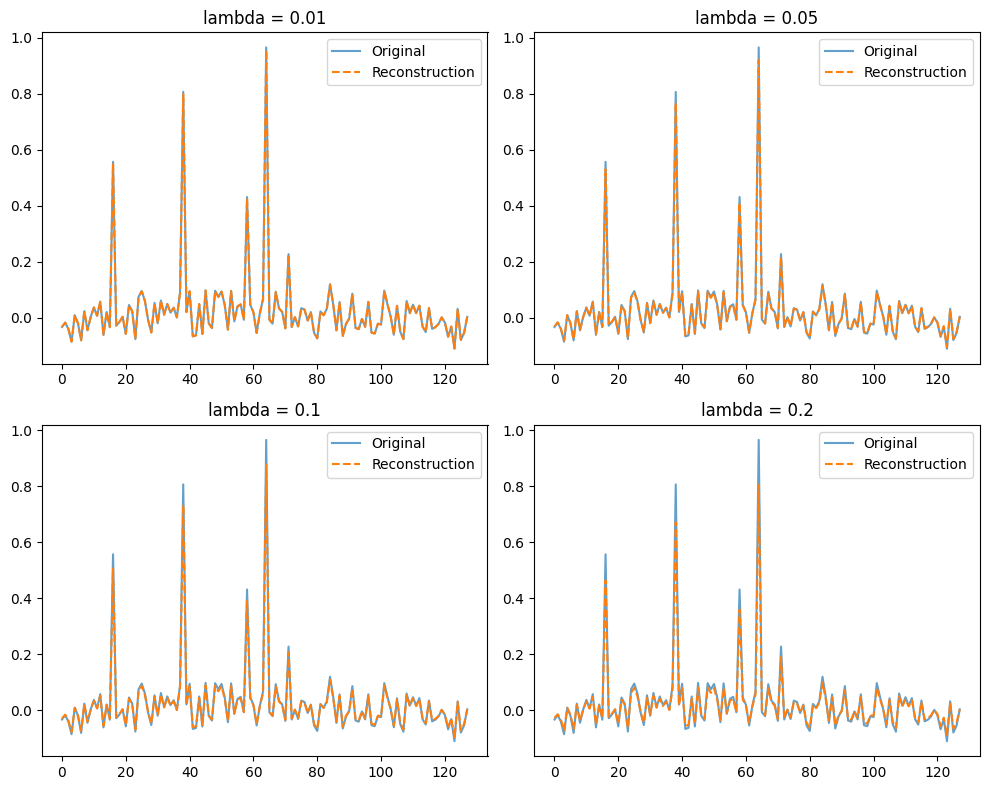

In [5]:
lambdas = [0.01, 0.05, 0.1, 0.2]

# TODO: Create a 2x2 subplot grid
# For each lambda:
#   1. Compute x_hat = y / (1 + lambda)
#   2. Plot original signal and reconstruction
#   3. Calculate and print error and sparsity (coefficients larger than a small threshold, let's use 0.01)

# YOUR CODE HERE

threshold = 0.01

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, lam in enumerate(lambdas):
    x_hat = y / (1 + lam)

    axes[i].plot(y, label="Original", alpha=0.7)
    axes[i].plot(x_hat, label="Reconstruction", linestyle="--")
    axes[i].set_title(f"lambda = {lam}")
    axes[i].legend()

    error = np.mean((y - x_hat) ** 2)

    sparsity = np.sum(np.abs(x_hat) > threshold)

    print(f"lambda={lam:.2f} | error={error:.4f} | sparsity={sparsity}")

plt.tight_layout()
plt.show()

No, this solution isn't truly sparse because it just shrinks the numbers, it doesn't really set most to zero while leaving a few peaks.

## 1b) Sparse Signals and the L1 Norm

Instead of Tikhonov regularization which penalizes the L2 norm, we will use an L1 norm penalized solution:

$$\hat{x} = \arg\min_x \frac{1}{2}\|x - y\|_2^2 + \lambda\|x\|_1$$

Since variables are independent, we can minimize each separately:

$$\hat{x}_i = \arg\min_{x_i} \frac{1}{2}|x_i - y_i|^2 + \lambda|x_i|$$

### Task 1.4: Derive soft thresholding

**Question 3**: Show that the solution is:

$$\hat{x} = \begin{cases}
y + \lambda & \text{if } y < -\lambda \\
0 & \text{if } |y| \leq \lambda \\
y - \lambda & \text{if } y > \lambda
\end{cases}$$

Hint: Consider the cases y >> λ, y << -λ, and |y| < λ separately.

(Differentiate)

### Task 1.5: Implement soft thresholding

Write a function `soft_threshold_real(y, lambda_)` that implements the soft thresholding operator for real-valued signals.

Then plot the function for y ∈ [-10, 10] and λ = 2.

In [6]:
def soft_threshold_real(y, lambda_):
    """
    Soft thresholding operator for real-valued signals.

    Args:
        y: Input signal
        lambda_: Threshold parameter

    Returns:
        x_hat: Thresholded signal
    """

    return np.sign(y) * np.maximum(np.abs(y) - lambda_, 0)

**Question 4**: Describe what happens when y is small compared to λ, and when y is large.

### Task 1.6: Apply soft thresholding to noisy signal

Apply `soft_threshold_real` to the noisy signal y with λ = {0.01, 0.05, 0.1, 0.2}.

**Question 5**: Is the solution sparse? Compare with Tikhonov regularization.

lambda=0.01 | error=0.0018 | nonzeros=101
lambda=0.05 | error=0.0004 | nonzeros=33
lambda=0.10 | error=0.0005 | nonzeros=7
lambda=0.20 | error=0.0016 | nonzeros=5


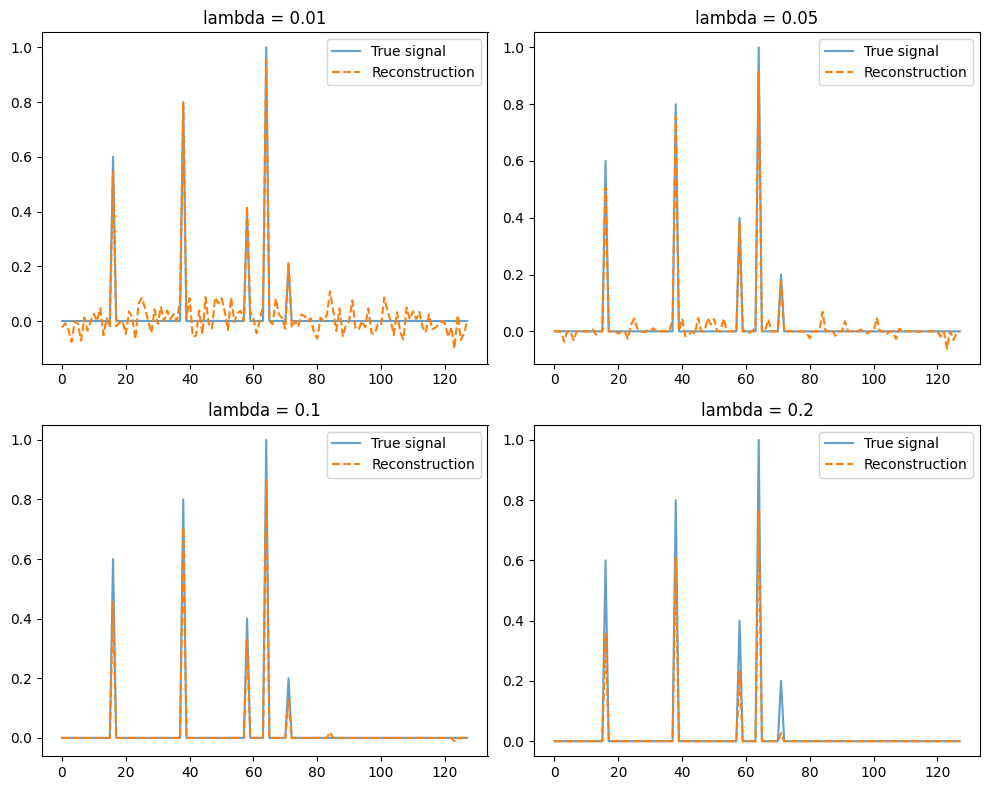

In [7]:
# Regenerate the signals (in case previous cells modified y)
np.random.seed(0)
N = 128
coefficients = np.arange(1, 6) / 5
x = np.zeros(N)
x[:5] = coefficients
x = np.random.permutation(x)
sigma = 0.05
n = sigma * np.random.randn(N)
y = x + n

lambdas = [0.01, 0.05, 0.1, 0.2]

# TODO: Apply soft thresholding with different lambdas
# Create 2x2 subplots
# For each lambda:
#   1. Apply soft_threshold_real
#   2. Plot original and reconstructed signals
#   3. Calculate and print error and sparsity

# YOU CODE HERE

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

threshold = 0.01

for i, lam in enumerate(lambdas):

    x_hat = soft_threshold_real(y, lam)

    axes[i].plot(x, label="True signal", alpha=0.7)
    axes[i].plot(x_hat, label="Reconstruction", linestyle="--")
    axes[i].set_title(f"lambda = {lam}")
    axes[i].legend()

    error = np.mean((x - x_hat) ** 2)

    sparsity = np.sum(np.abs(x_hat) > threshold)

    print(f"lambda={lam:.2f} | error={error:.4f} | nonzeros={sparsity}")

plt.tight_layout()
plt.show()

Yes, as we tune it up, a lot more "zero" solutions

## 1c) Random Frequency Domain Sampling and Aliasing

There is a strong connection between compressed sensing and denoising. We'll now explore this connection and the importance of incoherent sampling.

### Task 1.7: Equispaced undersampling

1. Compute the centered Fourier transform: `X = fftc(x)`
2. Undersample k-space by taking 32 **equispaced** samples (every 4th sample)
3. Compute inverse FFT with zero-filling and multiply by 4
4. Plot the result

**Question 6**: 
- Why is this the minimum L2 norm solution? 
- Describe what you see in the reconstruction
- Will we be able to reconstruct the original signal from this result?

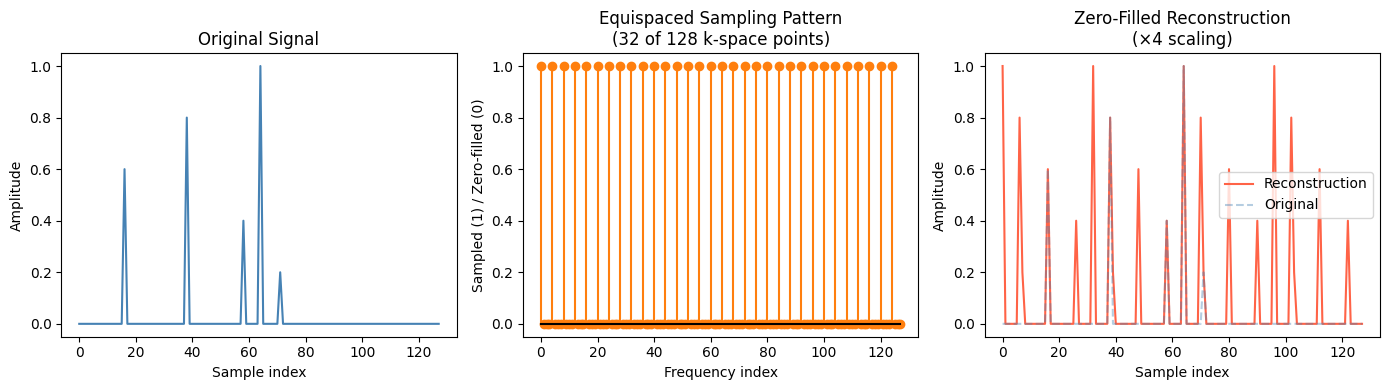

In [8]:
# TODO: Compute Fourier transform
X = fftc(x)  # YOUR CODE HERE

# TODO: Equispaced undersampling
Xu = np.zeros(N, dtype=complex)
# Take every 4th sample
# YOUR CODE HERE
Xu[::4] = X[::4]

# TODO: Zero-filled reconstruction
xu = 4 * ifftc(Xu)  # YOUR CODE HERE

# TODO: Create visualization with 3 subplots:
# 1. Original signal
# 2. Sampling pattern in k-space
# 3. Reconstructed signal

# YOUR CODE HERE
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(np.real(x), color="steelblue")
axes[0].set_title("Original Signal")
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Amplitude")

sampling_mask = (np.abs(Xu) > 0).astype(int)
axes[1].stem(np.arange(N), sampling_mask, markerfmt="C1o", linefmt="C1-", basefmt="k-")
axes[1].set_title("Equispaced Sampling Pattern\n(32 of 128 k-space points)")
axes[1].set_xlabel("Frequency index")
axes[1].set_ylabel("Sampled (1) / Zero-filled (0)")

axes[2].plot(np.real(xu), color="tomato", label="Reconstruction")
axes[2].plot(np.real(x), color="steelblue", alpha=0.4, linestyle="--", label="Original")
axes[2].set_title("Zero-Filled Reconstruction\n(×4 scaling)")
axes[2].set_xlabel("Sample index")
axes[2].set_ylabel("Amplitude")
axes[2].legend()

plt.tight_layout()
plt.savefig("equispaced_undersampling.png", dpi=150, bbox_inches="tight")
plt.show()

### Task 1.8: Random undersampling

Now undersample k-space by taking 32 samples at **random** locations.

**Question 7**: 
- Describe the result and compare with equispaced sampling
- Will we be able to reconstruct the signal from this result?
- How does this resemble the denoising problem?

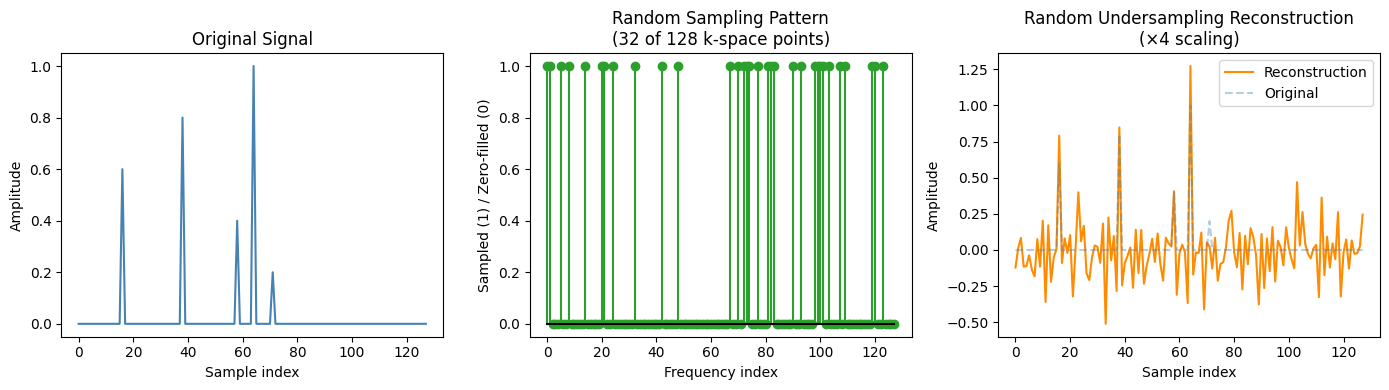

In [9]:
# TODO: Random undersampling
np.random.seed(30)
Xr = np.zeros(N, dtype=complex)
# Randomly select 32 locations
# YOUR CODE HERE
random_inds = np.random.choice(N, size=32, replace=False)
Xr[random_inds] = X[random_inds]

# TODO: Zero-filled reconstruction
xr = 4 * ifftc(Xr)  # YOUR CODE HERE

# TODO: Create visualization (same as above but for random sampling)
# YOUR CODE HERE

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(np.real(x), color="steelblue")
axes[0].set_title("Original Signal")
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Amplitude")

sampling_mask = np.zeros(N)
sampling_mask[random_inds] = 1
axes[1].stem(np.arange(N), sampling_mask, markerfmt="C2o", linefmt="C2-", basefmt="k-")
axes[1].set_title("Random Sampling Pattern\n(32 of 128 k-space points)")
axes[1].set_xlabel("Frequency index")
axes[1].set_ylabel("Sampled (1) / Zero-filled (0)")

# 3. Reconstructed signal
axes[2].plot(np.real(xr), color="darkorange", label="Reconstruction")
axes[2].plot(np.real(x), color="steelblue", alpha=0.4, linestyle="--", label="Original")
axes[2].set_title("Random Undersampling Reconstruction\n(×4 scaling)")
axes[2].set_xlabel("Sample index")
axes[2].set_ylabel("Amplitude")
axes[2].legend()

plt.tight_layout()
plt.savefig("random_undersampling.png", dpi=150, bbox_inches="tight")
plt.show()

## 1d) Reconstruction from Randomly Sampled Frequency Domain Data

Inspired by the denoising example, we will solve:

$$\hat{x} = \arg\min_x \frac{1}{2}\|F_u x - y\|_2^2 + \lambda\|x\|_1$$

We'll use a Projection Onto Convex Sets (POCS) algorithm:

1. Compute inverse FFT: $x_i = F^* X_i$
2. Apply soft threshold: $x_i = S(x_i, \lambda)$
3. Compute forward FFT: $X_i = F x_i$
4. Enforce data consistency: $X_i[j] = y[j]$ where $y[j] \neq 0$
5. Repeat until convergence

### Task 1.9: Implement soft thresholding for complex signals

For complex signals, soft thresholding becomes:

$$S(x, \lambda) = \begin{cases}
0 & \text{if } |x| \leq \lambda \\
\frac{|x| - \lambda}{|x|} x & \text{if } |x| > \lambda
\end{cases}$$

In [10]:
def soft_threshold(x, lambda_):
    """
    Soft thresholding for complex signals.

    Args:
        x: Complex input signal
        lambda_: Threshold parameter

    Returns:
        Thresholded signal
    """
    # TODO: Implement complex soft thresholding
    # YOUR CODE HERE
    scale = np.maximum(np.abs(x) - lambda_, 0) / np.maximum(np.abs(x), 1e-10)
    return scale * x


print("✓ Soft threshold function defined")

✓ Soft threshold function defined


### Task 1.10: Implement POCS algorithm

Implement the full POCS reconstruction algorithm.

In [11]:
def reconstruct_1d_pocs(Y, lambda_, max_iter=300, tol=1e-6):
    """
    1D POCS reconstruction.

    Args:
        Y: Undersampled k-space (zeros for non-acquired)
        lambda_: Soft threshold parameter
        max_iter: Maximum iterations
        tol: Convergence tolerance

    Returns:
        x_hat: Reconstructed signal
    """
    # TODO:
    # YOUR CODE HERE
    history = []
    acquired_mask = np.abs(Y) > 0

    Xi = Y.copy()
    xi = ifftc(Xi)

    for _ in range(max_iter):
        x_prev = xi.copy()
        xi = ifftc(Xi)
        xi = soft_threshold(xi, lambda_)
        Xi = fftc(xi)
        Xi[acquired_mask] = Y[acquired_mask]

        # convergence check
        x_current = ifftc(Xi)
        rel_change = np.linalg.norm(x_current - x_prev) / (
            np.linalg.norm(x_prev) + 1e-10
        )
        history.append(rel_change)
        if rel_change < tol:
            break

    # Final signal-domain reconstruction
    x_hat = ifftc(Xi)
    return x_hat, history


print("✓ POCS function defined")

✓ POCS function defined


### Task 1.11: Reconstruct from random sampling

Apply the POCS algorithm to the randomly undersampled signal with λ = {0.01, 0.05, 0.1}.

For each λ:
- Run at most 100 iterations
- Plot the reconstruction
- Plot error vs iteration number

**Question 8**: Which λ gives the best result? Why?

c:\Users\gmone\miniconda3\envs\cs4660\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\gmone\miniconda3\envs\cs4660\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


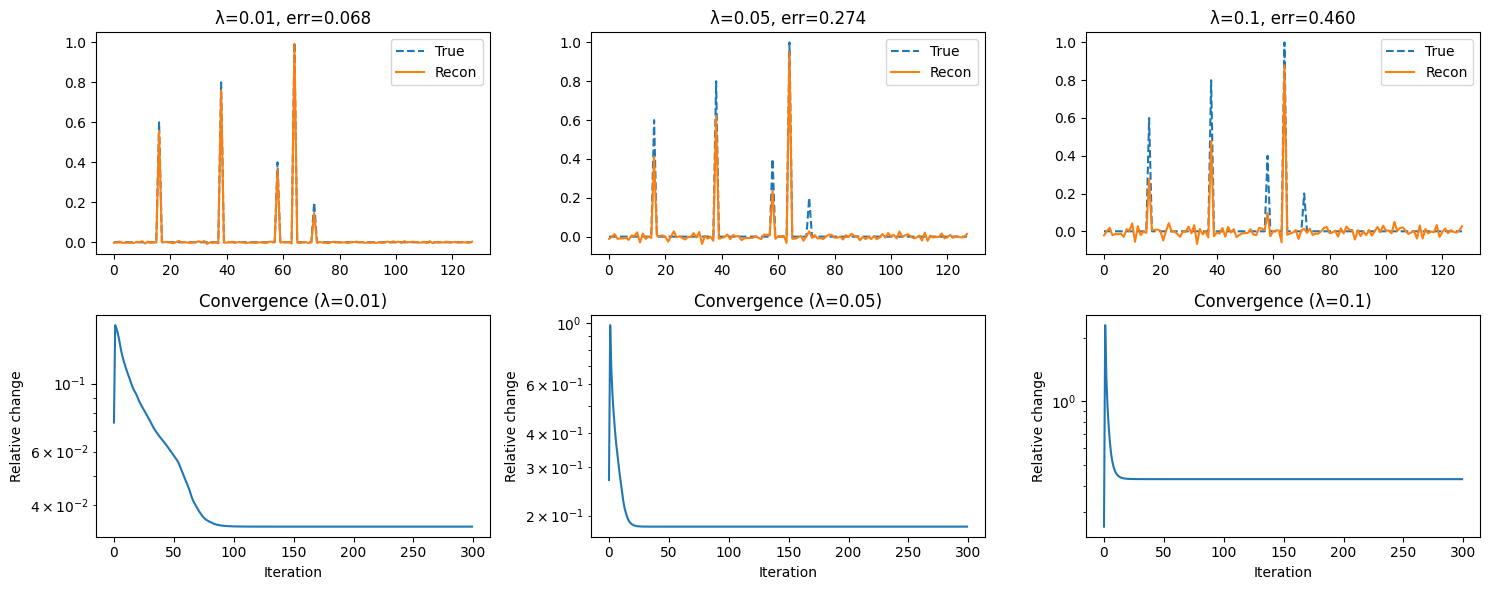

In [12]:
# TODO: Test different lambda values
lambdas_pocs = [0.01, 0.05, 0.1]

# TODO: For each lambda:
#   1. Run reconstruct_1d_pocs
#   2. Calculate error vs true signal
#   3. Store results

recons = []
errors = []
histories = []

for lam in lambdas_pocs:
    x_hat, hist = reconstruct_1d_pocs(Xr, lam)

    recons.append(x_hat)
    histories.append(hist)

    err = np.linalg.norm(x_hat - x) / np.linalg.norm(x)
    errors.append(err)

# TODO: Create visualization:
#   Top row: reconstructions for each lambda
#   Bottom row: convergence curves

# YOUR CODE HERE

plt.figure(figsize=(15, 6))

# --- Top row: reconstructions ---
for i, lam in enumerate(lambdas_pocs):
    plt.subplot(2, len(lambdas_pocs), i + 1)
    plt.plot(x, label="True", linestyle="--")
    plt.plot(recons[i], label="Recon")
    plt.title(f"λ={lam}, err={errors[i]:.3f}")
    plt.legend()

# --- Bottom row: convergence curves ---
for i, lam in enumerate(lambdas_pocs):
    plt.subplot(2, len(lambdas_pocs), len(lambdas_pocs) + i + 1)
    plt.plot(histories[i])
    plt.yscale("log")
    plt.title(f"Convergence (λ={lam})")
    plt.xlabel("Iteration")
    plt.ylabel("Relative change")

plt.tight_layout()
plt.show()

### Task 1.12: Try with equispaced sampling

Repeat the reconstruction for equispaced undersampled signal.

**Question 9**: What's wrong? Why doesn't it work?

Equispaced λ=0.01: error=0.8660, iters=1
Equispaced λ=0.05: error=0.8660, iters=1
Equispaced λ=0.1: error=0.8660, iters=1


C:\Users\gmone\AppData\Local\Temp\ipykernel_13668\366167081.py:28: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[1, i].set_yscale("log")


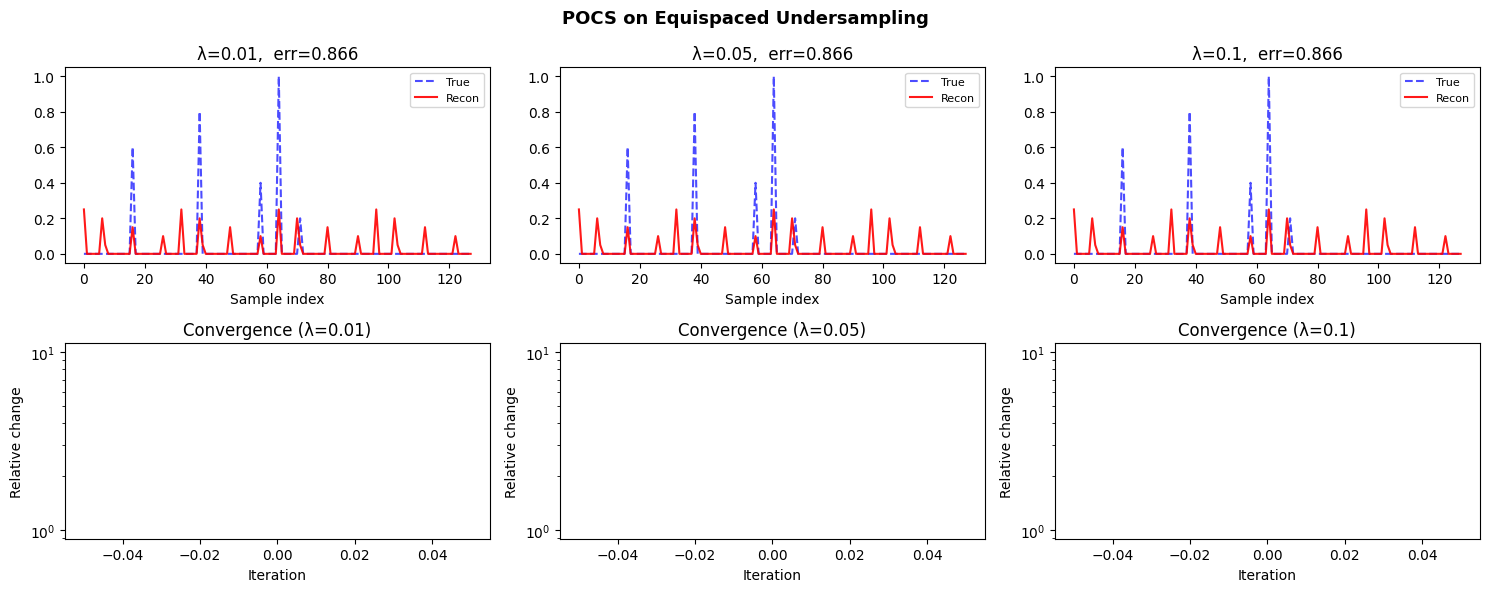

In [13]:
# TODO: Apply POCS to equispaced sampling
# YOUR CODE HERE

Xe = np.zeros(N, dtype=complex)
Xe[::4] = X[::4]

recons_eq, errors_eq, histories_eq = [], [], []
for lam in lambdas_pocs:
    x_hat_eq, hist_eq = reconstruct_1d_pocs(Xe, lam)
    recons_eq.append(x_hat_eq)
    histories_eq.append(hist_eq)
    err = np.linalg.norm(x_hat_eq - x) / np.linalg.norm(x)
    errors_eq.append(err)
    print(f"Equispaced λ={lam}: error={err:.4f}, iters={len(hist_eq)}")

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
fig.suptitle("POCS on Equispaced Undersampling", fontsize=13, fontweight="bold")

for i, lam in enumerate(lambdas_pocs):

    axes[0, i].plot(np.real(x), "b--", label="True", alpha=0.7)
    axes[0, i].plot(np.real(recons_eq[i]), "r", label="Recon", alpha=0.9)
    axes[0, i].set_title(f"λ={lam},  err={errors_eq[i]:.3f}")
    axes[0, i].set_xlabel("Sample index")
    axes[0, i].legend(fontsize=8)

    axes[1, i].plot(histories_eq[i])
    axes[1, i].set_yscale("log")
    axes[1, i].set_title(f"Convergence (λ={lam})")
    axes[1, i].set_xlabel("Iteration")
    axes[1, i].set_ylabel("Relative change")

plt.tight_layout()
plt.show()

---
# Part 2: Sparsity of Medical Images

Most medical images are not sparse in the pixel domain. However, they can have a sparser representation in a transform domain, such as the wavelet domain.

## Task 2.1: Load and display brain image

Load `brain.mat` and display the image.

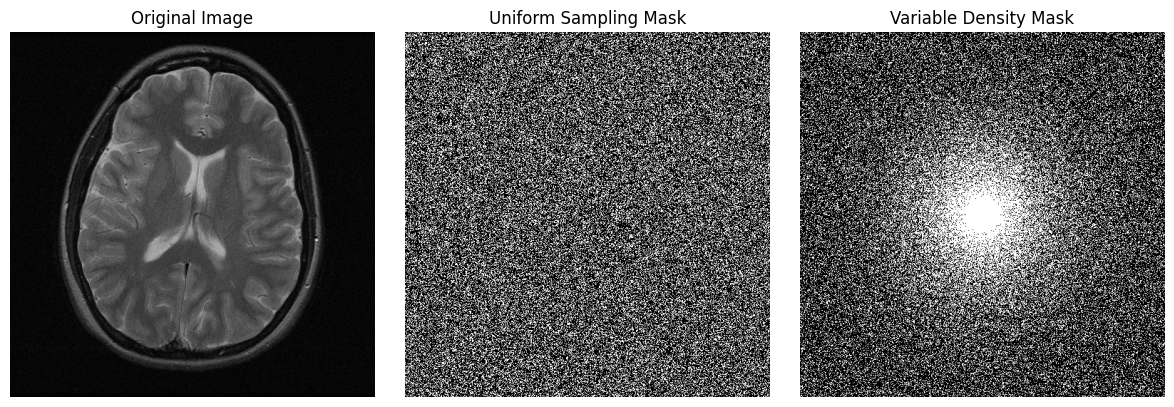

In [14]:
# TODO: Load brain.mat
data = scipy.io.loadmat("brain.mat")

# TODO: Extract variables
im = data["im"]
mask_unif = data["mask_unif"]
mask_vardens = data["mask_vardens"]
pdf_unif = data["pdf_unif"]
pdf_vardens = data["pdf_vardens"]

# TODO: Display the image and masks
# YOUR CODE HERE
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.abs(im), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_unif, cmap="gray")
plt.title("Uniform Sampling Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask_vardens, cmap="gray")
plt.title("Variable Density Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

## Task 2.2: Wavelet transform

Helper functions for wavelet transform are provided:

In [15]:
def wavelet_transform_2d(img, wavelet="db4", level=4):
    """2D wavelet transform."""
    coeffs = pywt.wavedec2(img, wavelet, mode="periodization", level=level)
    arr, slices = pywt.coeffs_to_array(coeffs)
    return arr, coeffs, slices


def wavelet_inverse_2d(arr, coeffs, slices, wavelet="db4"):
    """2D inverse wavelet transform."""
    coeffs_from_arr = pywt.array_to_coeffs(arr, slices, output_format="wavedec2")
    return pywt.waverec2(coeffs_from_arr, wavelet, mode="periodization")


print("✓ Wavelet functions defined")

✓ Wavelet functions defined


### Task 2.3: Compute and visualize wavelet coefficients

1. Compute the wavelet transform of the brain image
2. Plot the wavelet coefficients in log scale
3. Plot histogram of coefficient magnitudes

**Question 10**: What do you observe about the distribution of wavelet coefficients?

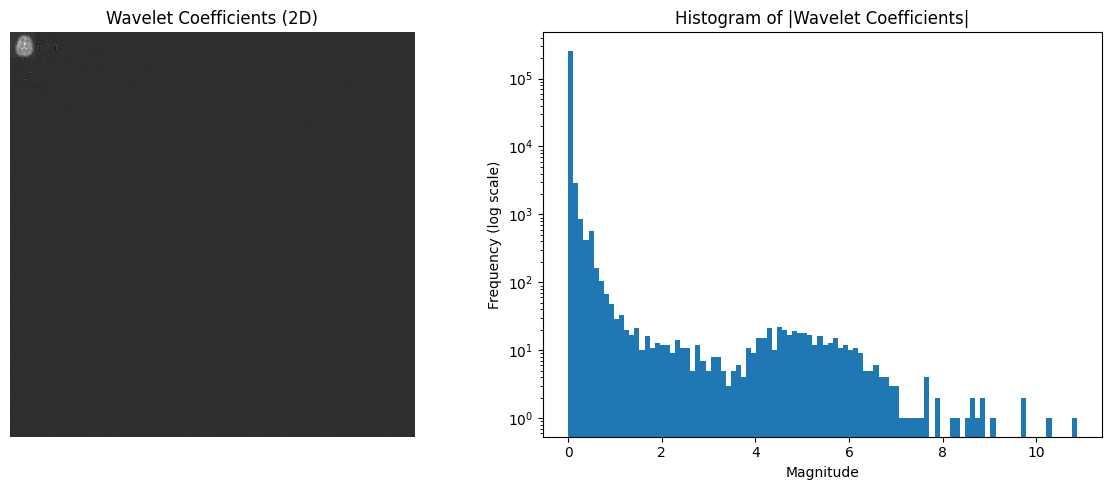

In [16]:
# TODO: Compute wavelet transform
# YOUR CODE HERE
arr, coeffs, slices = wavelet_transform_2d(np.abs(im))

# TODO: Visualize coefficients and histogram
# YOUR CODE HERE

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(arr, cmap="gray")
plt.title("Wavelet Coefficients (2D)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(np.abs(arr).ravel(), bins=100, log=True)
plt.title("Histogram of |Wavelet Coefficients|")
plt.xlabel("Magnitude")
plt.ylabel("Frequency (log scale)")

plt.tight_layout()
plt.show()

## Task 2.4: Threshold wavelet coefficients

Implement a function to threshold wavelet coefficients, keeping only the largest fraction:

In [17]:
def threshold_wavelet_coeffs(im_w, fraction):
    """
    Keep only the largest fraction of coefficients.

    Args:
        im_w: Wavelet coefficients
        fraction: Fraction of coefficients to keep (0 to 1)

    Returns:
        im_w_th: Thresholded coefficients
        thresh: Threshold value used
    """
    # TODO:
    # 1. Sort absolute values in descending order
    # 2. Find threshold at given fraction
    # 3. Zero out coefficients below threshold
    flat = np.abs(im_w).ravel()
    sorted_vals = np.sort(flat)[::-1]
    k = int(fraction * len(sorted_vals))
    k = max(k, 1)

    thresh = sorted_vals[k - 1]

    im_w_th = im_w.copy()
    im_w_th[np.abs(im_w_th) < thresh] = 0

    return im_w_th, thresh

### Task 2.5: Test sparse approximation

Threshold the wavelet coefficients retaining the largest 20%, 12.5%, 10%, 5%, and 2.5%.

For each fraction:
- Reconstruct the image
- Display the reconstruction
- Compute and display the difference image
- Calculate reconstruction error

**Question 11**: 
- What has been thresholded?
- What has been removed in the difference image?
- What, in your opinion, is the sparsity of the image? Provide a reconstruction and difference image to support your argument.

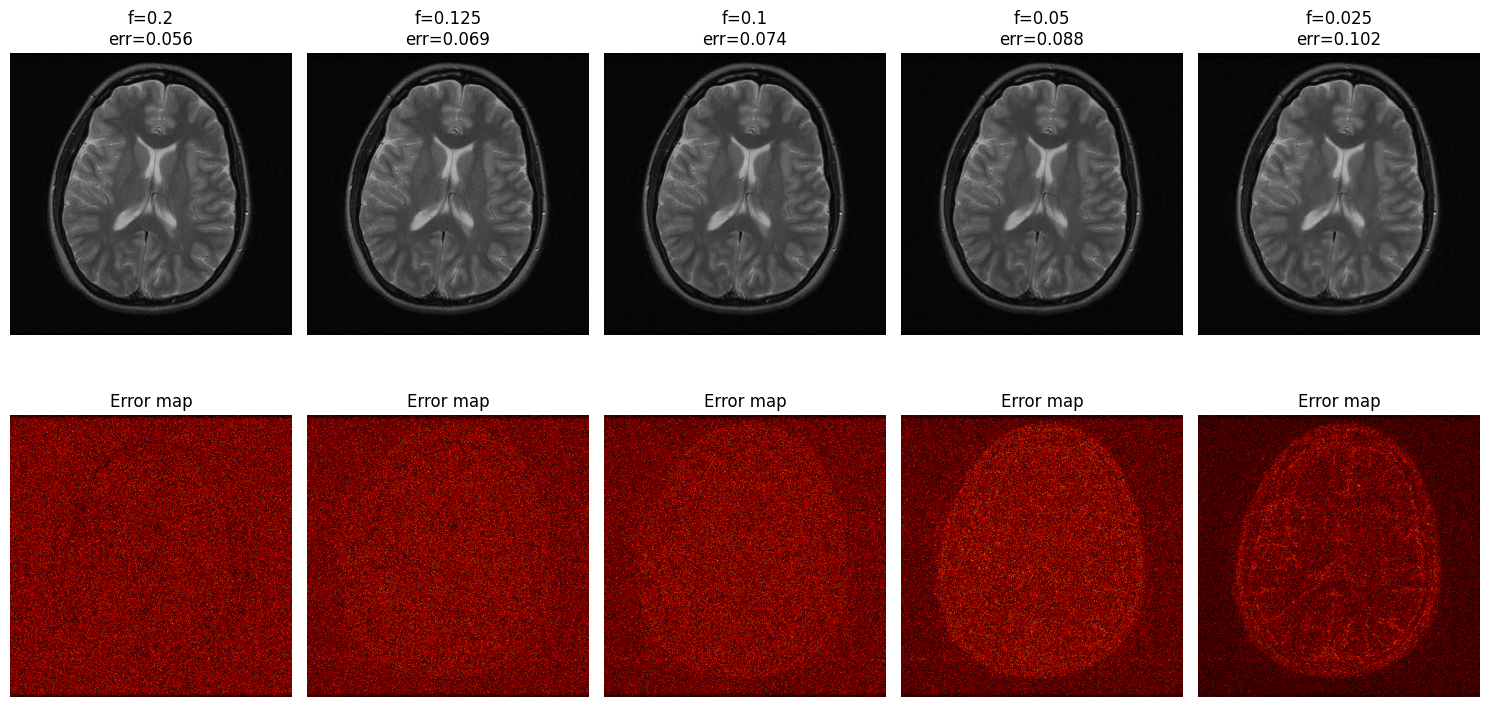

In [18]:
# TODO: Test different sparsity levels
fractions = [0.20, 0.125, 0.10, 0.05, 0.025]

# TODO: Create visualization grid
# For each fraction:
#   1. Threshold coefficients
#   2. Reconstruct image
#   3. Calculate error
#   4. Display

# YOUR CODE HERE

recons = []
errors = []
thresholds = []

im_true = np.abs(im)

for f in fractions:

    im_w, coeffs, slices = wavelet_transform_2d(im_true)
    im_w_th, thresh = threshold_wavelet_coeffs(im_w, f)
    im_rec = wavelet_inverse_2d(im_w_th, coeffs, slices)

    err = np.linalg.norm(im_rec - im_true) / np.linalg.norm(im_true)

    recons.append(im_rec)
    errors.append(err)
    thresholds.append(thresh)

plt.figure(figsize=(15, 8))


for i, f in enumerate(fractions):
    plt.subplot(2, len(fractions), i + 1)
    plt.imshow(np.abs(recons[i]), cmap="gray")
    plt.title(f"f={f}\nerr={errors[i]:.3f}")
    plt.axis("off")

for i, f in enumerate(fractions):
    plt.subplot(2, len(fractions), len(fractions) + i + 1)
    diff = np.abs(np.abs(recons[i]) - im_true)
    plt.imshow(diff, cmap="hot")
    plt.title("Error map")
    plt.axis("off")

plt.tight_layout()
plt.show()

---
# Part 3: Compressed Sensing Reconstruction

Now we'll explore 2D compressed sensing reconstruction from undersampled data.

## 3a) Non-Uniform Random Sampling

### Task 3.1: Uniform sampling pattern

1. Compute 2D FFT of the image
2. Apply uniform sampling mask
3. Divide by PDF for density compensation
4. Compute zero-filled inverse FFT
5. Display results

**Question 12**: Is the aliasing white random noise? Describe what you see.

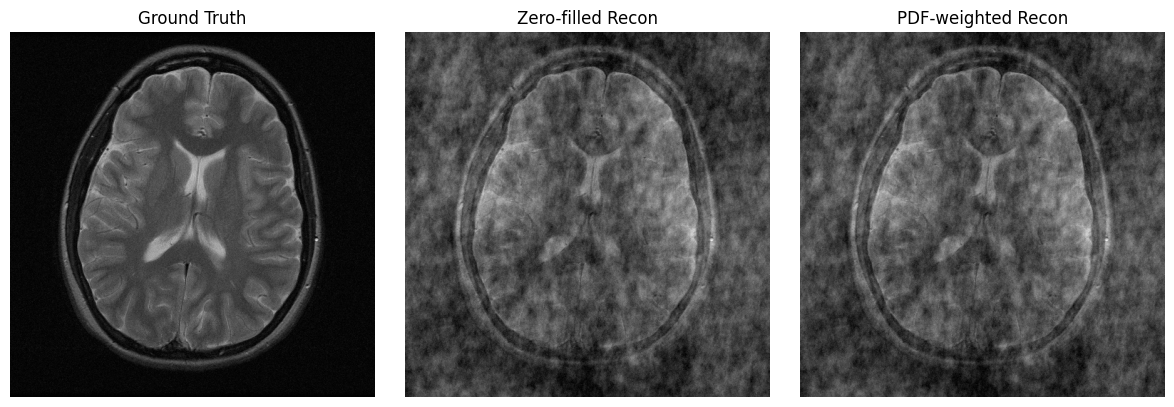

In [19]:
# TODO: Uniform sampling reconstruction
M = fft2c(im)

# TODO: Apply mask and PDF compensation
# YOUR CODE HERE
Mu = M * mask_unif
M_compensated = Mu / (pdf_unif + 1e-8)

# TODO: Zero-filled reconstruction
# YOUR CODE HERE
x_zf = ifft2c(Mu)
x_comp = ifft2c(M_compensated)

# TODO: Display results
# YOUR CODE HERE

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.abs(im), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.abs(x_zf), cmap="gray")
plt.title("Zero-filled Recon")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.abs(x_comp), cmap="gray")
plt.title("PDF-weighted Recon")
plt.axis("off")

plt.tight_layout()
plt.show()

### Task 3.2: Variable density sampling

Repeat for variable density mask.

**Question 13**: 
- What happened now?
- Both use similar number of samples, but which gives better reconstruction?

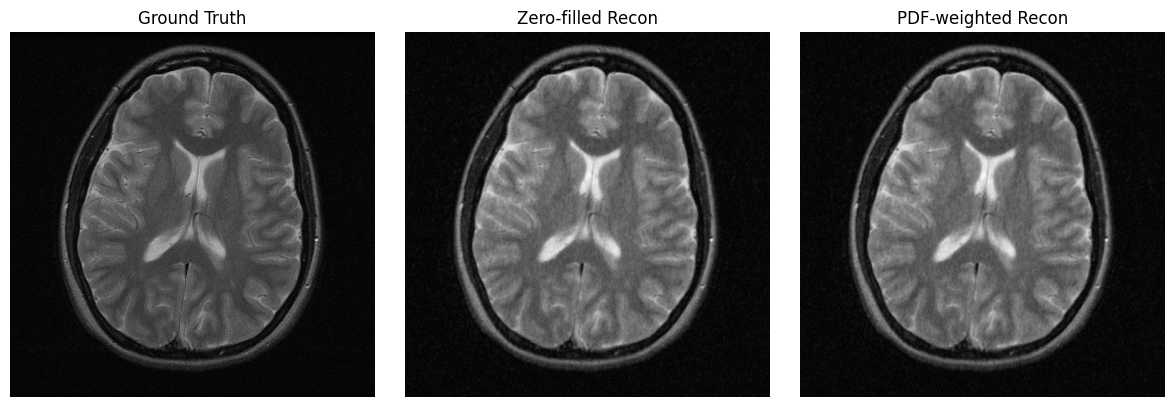

In [20]:
# TODO: Variable density sampling reconstruction
# YOUR CODE HERE

# TODO: Uniform sampling reconstruction
M = fft2c(im)

# TODO: Apply mask and PDF compensation
# YOUR CODE HERE
Mu = M * mask_vardens
M_compensated = Mu / (pdf_unif + 1e-8)

# TODO: Zero-filled reconstruction
# YOUR CODE HERE
x_zf = ifft2c(Mu)
x_comp = ifft2c(M_compensated)

# TODO: Display results
# YOUR CODE HERE

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.abs(im), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.abs(x_zf), cmap="gray")
plt.title("Zero-filled Recon")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.abs(x_comp), cmap="gray")
plt.title("PDF-weighted Recon")
plt.axis("off")

plt.tight_layout()
plt.show()

## 3b) Reconstruction from Random Sampled k-Space Data

Implement the POCS algorithm for 2D images with wavelet sparsity.

Algorithm:
1. Inverse FFT to image domain: $x_i = F^* X_i$
2. **Wavelet transform**: $x_w = W(|x_i|)$
3. Soft threshold in wavelet domain: $x_w = S(x_w, \lambda)$
4. **Inverse wavelet transform**: $x_i = W^{-1}(x_w) \cdot e^{j\angle x_i}$
5. Forward FFT: $X_i = F x_i$
6. Data consistency: $X_i[\text{mask}] = Y[\text{mask}]$

In [56]:
def reconstruct_2d_pocs_wavelet(
    Y, mask, pdf, lambda_, max_iter=50, true_image=None, wavelet="db4", level=4
):
    """
    2D POCS reconstruction with wavelet sparsity.

    Args:
        Y: Acquired k-space data
        mask: Sampling mask
        pdf: Probability density function
        lambda_: Soft threshold parameter
        max_iter: Maximum iterations
        true_image: Original image for error calculation (optional)

    Returns:
        recon: Reconstructed image
    """
    # TODO: Inplementation here
    # YOUR CODE HERE

    history = []
    eps = 1e-8
    safe_pdf = np.where(mask > 0, pdf, 1.0)
    xi = ifft2c(Y / (safe_pdf + eps))

    for _ in range(max_iter):
        x_prev = xi.copy()
        phase = np.angle(xi)
        real, coeffs_r, slices_r = wavelet_transform_2d(np.real(xi), wavelet=wavelet, level=level)
        imag, coeffs_i, slices_i = wavelet_transform_2d(np.imag(xi), wavelet=wavelet, level=level)

        real_thresh = soft_threshold(real, lambda_)
        imag_thresh = soft_threshold(imag, lambda_)

        xi = wavelet_inverse_2d(real_thresh, coeffs=coeffs_r, slices=slices_r, wavelet=wavelet) + 1j * wavelet_inverse_2d(imag_thresh,coeffs=coeffs_i, slices=slices_i, wavelet=wavelet)
        alpha = 0.5  # try 0.1–0.7
        
        xi = (1 - alpha) * x_prev + alpha * xi

        Xi = fft2c(xi)
        Xi[mask > 0] = Y[mask > 0]

        xi = ifft2c(Xi)

        if true_image is not None:
            err = np.linalg.norm(np.abs(xi) - true_image) / np.linalg.norm(true_image)
            print(err)
        else:
            err = np.linalg.norm(xi - x_prev) / (np.linalg.norm(x_prev) + 1e-10)

        history.append(err)

    return xi, history


print("✓ 2D POCS function defined")

✓ 2D POCS function defined


### Task 3.4: Find appropriate λ testue

Before reconstruction, visualize which coefficients would be thresholded for different λ values.

You want a significant number of coefficients below λ, but not all of them.

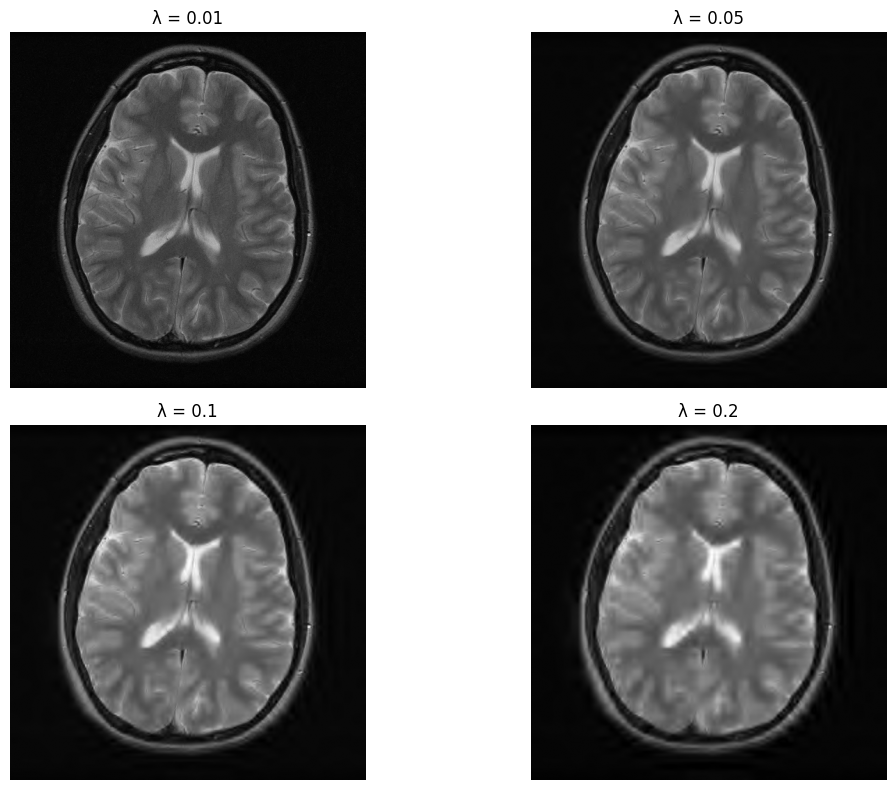

In [42]:
# TODO: Test different lambda values
# Compute wavelet transform of zero-filled reconstruction
# For each lambda, show which coefficients would be retained

# YOUR CODE HERE

X = fft2c(im * mask_vardens)
x_zf = ifft2c(X)
x_zf = np.abs(x_zf)

im_w, coeffs, slices = wavelet_transform_2d(x_zf)

lambdas = [0.01, 0.05, 0.1, 0.2]

plt.figure(figsize=(12, 8))

for i, lam in enumerate(lambdas):
    arr_thresh = soft_threshold(arr, lam)
    retained_pct = (np.count_nonzero(arr_thresh) / arr.size) * 100
    im_rec = wavelet_inverse_2d(arr_thresh, coeffs, slices, wavelet="db4")

    plt.subplot(2, 2, i + 1)
    plt.imshow(np.abs(im_rec), cmap="gray")
    plt.title(f"λ = {lam}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Task 3.5: Reconstruct from variable density data

1. Start with variable density data
2. Experiment with several λ values
3. Run 100 iterations
4. Compare results

**Question 14**: 
- Show the reconstructed image and difference image for your best λ
- Compare to zero-filled reconstruction
- What improvement do you see?

0.10080475846909889
0.10003622107839213
0.09973827206977975
0.09960671675425455
0.09954020872963057
0.09950174879466593
0.09947752207566951
0.09946177943976474
0.0994512773258667
0.09944413862907113
0.09943922190119997
0.09943573370385207
0.09943325047564916
0.09943149668101915
0.09943026057617495
0.09942940213845944
0.09942881797897063
0.09942842324775028
0.09942815394229816
0.09942796853938818
0.09942783915836981
0.09942775070667789
0.09942769065828763
0.09942765159005328
0.09942762752988042
0.09942761387876535
0.09942760729383714
0.0994276053278741
0.09942760627600963
0.09942760896814523
0.09942761261403549
0.09942761669022354
0.09942762085873537
0.09942762490922591
0.09942762871814796
0.09942763222013723
0.0994276353880949
0.09942763821942648
0.09942764072661654
0.09942764293084407
0.0994276448577194
0.09942764653449457
0.09942764798828886
0.09942764924500903
0.09942765032873876
0.09942765126144097
0.0994276520628635
0.09942765275057378
0.09942765334007053
0.09942765384493882
0.099

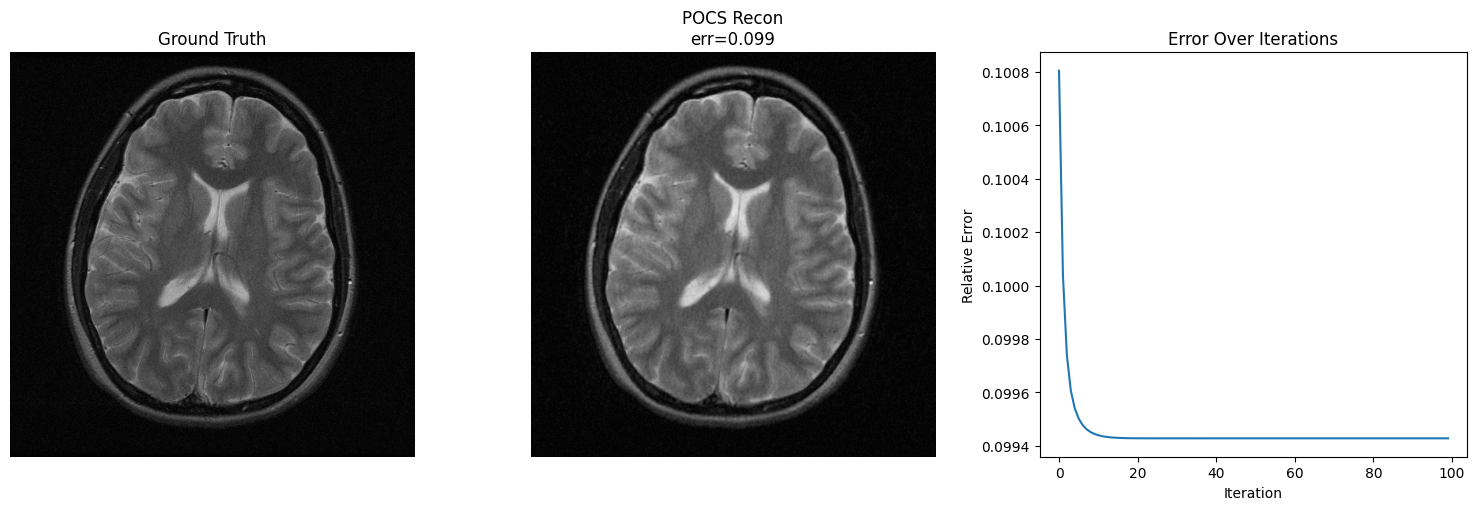

In [57]:
# TODO: Reconstruct from variable density sampling
Y_vardens = M * mask_vardens

# TODO: Choose lambda and run reconstruction
# YOUR CODE HERE
lambda_ = 0.1

recon_vd, history_vd = reconstruct_2d_pocs_wavelet(
    Y_vardens, mask_vardens, pdf_vardens, lambda_, max_iter=100, true_image=np.abs(im)
)

# TODO: Display results with error analysis
# YOUR CODE HERE

true_image = np.abs(im)

rel_error = np.linalg.norm(np.abs(recon_vd) - true_image) / np.linalg.norm(true_image)
print("Reconstruction error:", rel_error)

# For zero-filled comparison
x_zf = ifft2c(Y_vardens)
rel_error_zf = np.linalg.norm(np.abs(x_zf) - true_image) / np.linalg.norm(true_image)
print("Zero-filled error:", rel_error_zf)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(np.abs(im), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.abs(recon_vd), cmap="gray")
plt.title(f"POCS Recon\nerr={rel_error:.3f}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.plot(history_vd)
plt.title("Error Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Relative Error")

plt.tight_layout()
plt.show()


---
# Summary and Reflection

**Question 15**: In a few paragraphs, summarize:

1. What you learned about compressed sensing
2. The three key principles (sparsity, incoherence, nonlinear reconstruction)
3. Why random sampling is crucial
4. The connection between compressed sensing and denoising
5. Potential applications in medical imaging

Take the origional Model from this:
-Denoising: Soft thresholding
-Forward Model: Wavelet 
-Inverse Model: POCS

And make the following changes to compare:
-Denoising: Soft thresholding + Plug and Play Priors
-Forward Model: Wavelet
-Inverse Model: FISTA (Tv)

### PnP (Plug-and-Play Prior Setup)

Imports

In [24]:
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision.datasets import ImageNet
import pandas as pd
from pathlib import Path
from PIL import Image
import deepinv as dinv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c:\Users\gmone\miniconda3\envs\cs4660\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
model = dinv.models.DRUNet()
model.eval()


def PnPDenoiser(x, sigma=0.1):
    with torch.no_grad():
        x_input = torch.from_numpy(x)[None, None].to(device, dtype=torch.float32)
        x_denoised = model(x_input, sigma)
        return x_denoised.squeeze().cpu().numpy().clip(0, 1)